In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sys
import importlib
from tqdm import tqdm

import os
os.environ['CUDA_PATH'] = '/apps/compilers/cuda/13.2.1' 

import torch
print(f"number of available GPUs = {torch.cuda.device_count()}")
output_device = 'cuda:0'

import vcme
from vcme.functions import prepare_proteingym_data
from vcme.utils import yeast_data, clear_gpu_mem, reload_obj, get_pathway_info
from vcme.utils import tensor_scatter, read_marginal_results, get_gene_interval
from vcme.utils import YeastMetadata

from epik.utils import encode_seqs, split_training_test

import epikVC
from epikVC.models import GPModel, make_GP_model, load_GP_model

fig_path = 'figures/'
result_path = 'results/'

wd = '/blue/juannanzhou/juannanzhou/vcme_project/'
checkpoint_path = wd + 'model_checkpoints/37C_r2_threshold=None_MAF_threshold=0/'

geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
pheno_path = "/orange/juannanzhou/dryad_data/"
pheno_name = '37C'
model_name = 'GP_model_k=8.model'

data = yeast_data(geno_path, pheno_path, pheno_name, output_device, prune_snps=False, r2_threshold=None, maf_threshold=0, top_percent=25)

snp_info_path = wd + "data/yeast/snp_info_final.csv"
pathway_info_path = wd + "data/yeast/all_pathway_gene_tables.tsv"

genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)
snp_info = genomic_meta_data.snp_info
gene_info = genomic_meta_data.gene_info
gene_info = gene_info.set_index('gene_standard_name')

genes = snp_info.gene_standard_name.unique()

gene_snps = {}

for g in genes:
    snps = snp_info.index[snp_info.gene_standard_name == g]
    gene_snps[g] = snps
        

number of available GPUs = 1
[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK
Loading yeast dataset
Using all snps
Finished loading
number of pathways = 123
number of genes in pathways = 355


### Specific pairwise interactions

In [201]:
import yeast_analysis.gene_hub_analysis
importlib.reload(yeast_analysis.gene_hub_analysis)

from yeast_analysis.gene_hub_analysis import epistatic_coefficient_onehot, sample_epistatic_coefficients, plot_epistatic_parallelogram_gene_onehot

In [33]:
# genotypes, fitness = data.X, data.y

# n_samples = 10_000

# epsilons, valid_pairs, failed_pairs = (
#     sample_epistatic_coefficients(
#         genotypes,
#         fitness,
#         n_samples=n_samples,
#         seed=42,
#     )
# )

# print(f"Successful pairs: {len(valid_pairs)}")
# print(f"Failed pairs: {len(failed_pairs)}")

# null_dist = epsilons ** 2
# null_dist = null_dist.cpu().numpy()

# plt.hist(null_dist, bins=100)
# plt.show()

In [ ]:
# import yeast_analysis.gene_hub_analysis
# importlib.reload(yeast_analysis.gene_hub_analysis)

# from yeast_analysis.gene_hub_analysis import (
#     epistatic_coefficient_gene_onehot,
#     plot_epistatic_parallelogram_gene_onehot,
# )

# epsilon, details = epistatic_coefficient_gene_onehot(
#     genotypes, fitness,
#     i="LMO1", j="SMA1",
#     snp_info="snp_info.csv",
#     return_details=True,
# )

# fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(
#     genotypes, fitness,
#     i="LMO1", j="SMA1",
#     snp_info="snp_info.csv",
#     bootstrap_errors=True,
#     p=
# )

In [29]:
null_epistatic_coefficients, valid_gene_pairs, failed_gene_pairs = (
    sample_epistatic_coefficients(
        genotypes,
        fitness,
        n_samples=10_000,
        seed=42,
        snp_info='snp_info.csv',
    )
)

In [209]:
yticks_ = np.arange(-0.5, -0.1, 0.02)
yticks = np.array([-0.24, -0.21, -0.19])
fontsize = 19

/tmp/ipykernel_1219171/1218861543.py:1: UserWarning: Excluded 264 samples with mixed within-gene haplotypes
  fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(


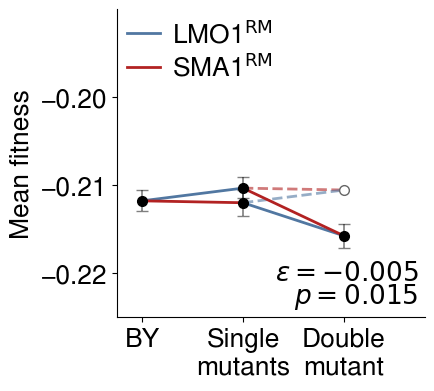

In [210]:
fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(
    genotypes,
    fitness,
    i="LMO1",
    j="SMA1",
    null_p_dist=null_epistatic_coefficients,
    bootstrap_errors=True,
    yticks=[-.22, -0.21, -.2],    
    ylim=[-.225, -0.19],
    fontsize=fontsize,
    errorbar_alpha=0.5,
    fig_path=fig_path
)

/tmp/ipykernel_1219171/585653301.py:3: UserWarning: Excluded 331 samples with mixed within-gene haplotypes
  fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(


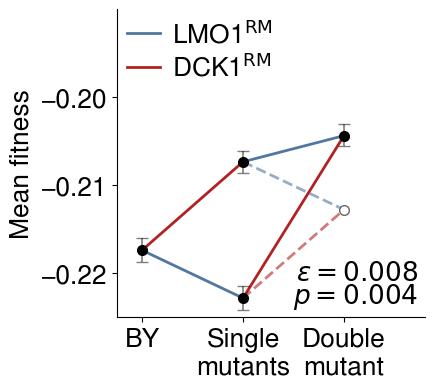

In [211]:
gene_i, gene_j = 'LMO1', 'DCK1'

fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(
    genotypes,
    fitness,
    i=gene_i,
    j=gene_j,
    null_p_dist=null_epistatic_coefficients,
    bootstrap_errors=True,
    yticks=[-.22, -0.21, -.2],    
    ylim=[-.225, -0.19],
    fontsize=fontsize,
    errorbar_alpha=0.5,
    fig_path=fig_path
)

/tmp/ipykernel_1219171/2447171934.py:3: UserWarning: Excluded 278 samples with mixed within-gene haplotypes
  fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(


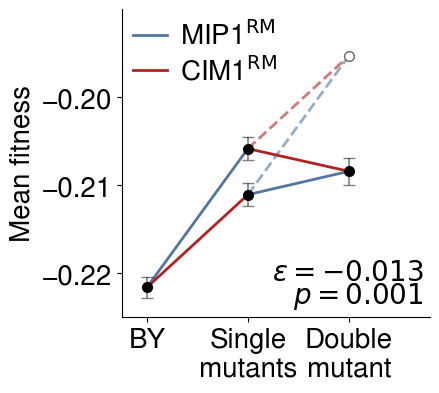

In [212]:
gene_i, gene_j = 'MIP1', 'CIM1'

fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(
    genotypes,
    fitness,
    i=gene_i,
    j=gene_j,
    null_p_dist=null_epistatic_coefficients,
    bootstrap_errors=True,
    yticks=[-.22, -0.21, -.2],    
    ylim=[-.225, -0.19],
    fontsize=20,
    errorbar_alpha=0.5,
    fig_path=fig_path    
)

/tmp/ipykernel_1219171/3806532113.py:3: UserWarning: Excluded 381 samples with mixed within-gene haplotypes
  fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(


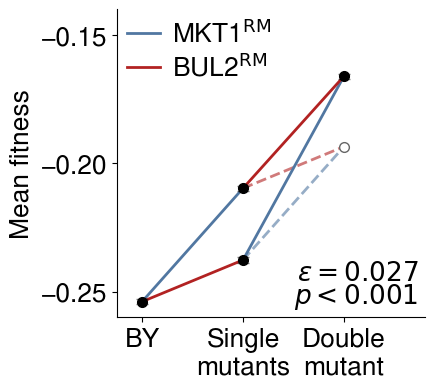

In [213]:
gene_i, gene_j = 'MKT1', 'BUL2'

fig, ax, epsilon = plot_epistatic_parallelogram_gene_onehot(
    genotypes,
    fitness,
    i=gene_i,
    j=gene_j,
    null_p_dist=null_epistatic_coefficients,
    bootstrap_errors=True,
    ylim=[-0.26, -0.14],
    yticks=[-0.25, -0.2, -0.15],
    fontsize=fontsize,
    errorbar_alpha=0.5,
    fig_path=fig_path    
)

### MIP1 vs CIM1

In [4]:
i, j = gene_snps['CIM1'][0], gene_snps['MIP1'][0]

In [5]:
i = 39501
j = 38306

epsilon_ij = epistatic_coefficient_onehot(genotypes, fitness, i=i, j=j)

print(epsilon_ij)

tensor(-0.0129, device='cuda:0')


In [6]:
np.sum(null_dist < (epsilon_ij ** 2 ).item())/n_samples

np.float64(0.9987)

In [7]:
hub_genes = list(pd.read_csv(result_path + 'df_hub_interactions.tsv', index_col=0).columns[:-1])

MKT1 MIP1


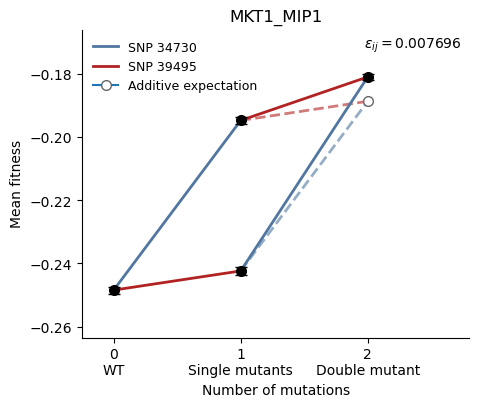

MKT1 HAL9


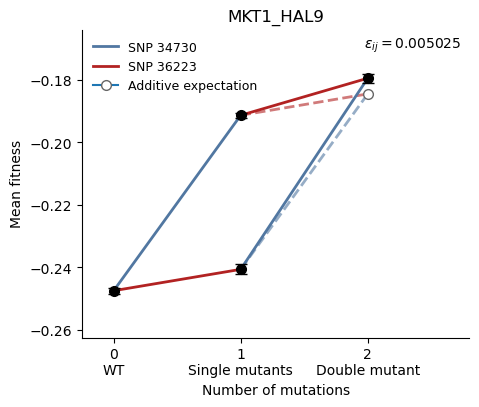

MKT1 LMO1


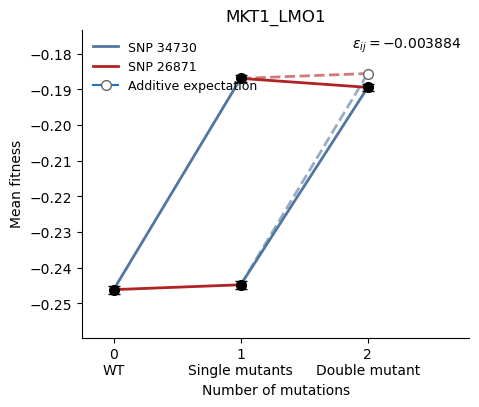

MKT1 VPS70


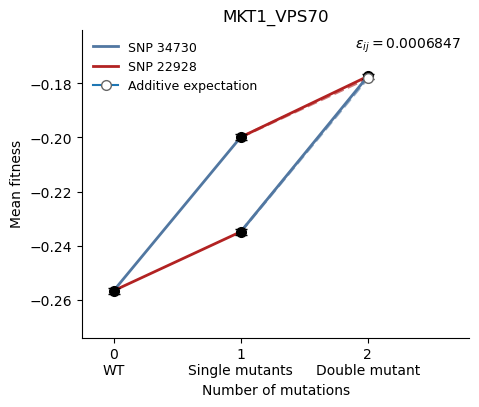

MKT1 BUL2


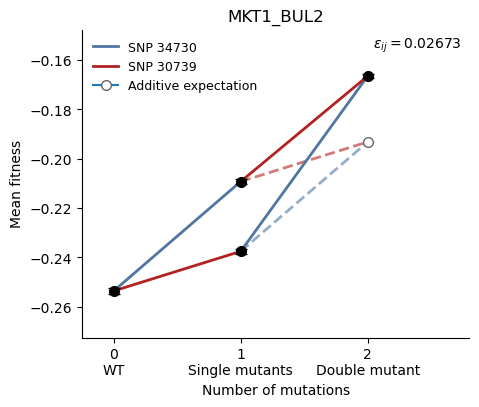

MKT1 VPS36


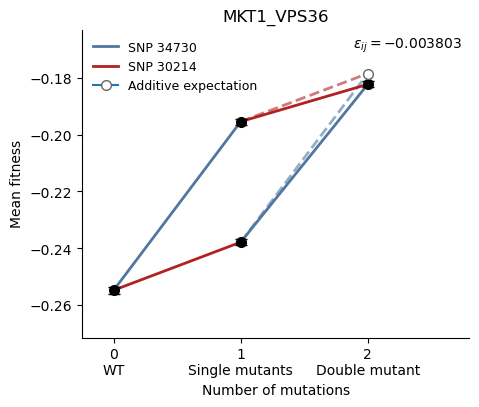

MKT1 RSF1


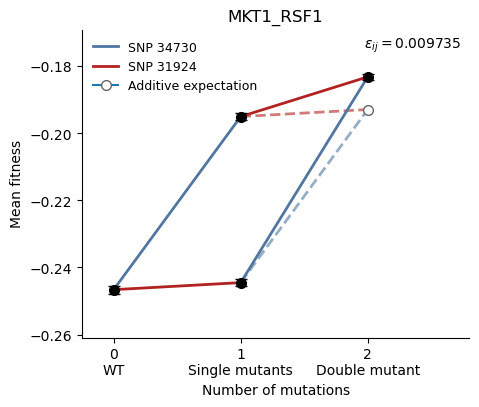

MIP1 HAL9


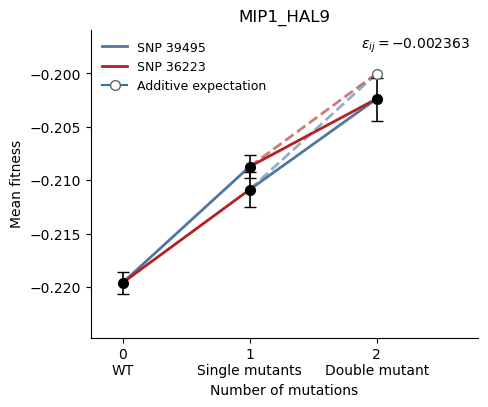

MIP1 LMO1


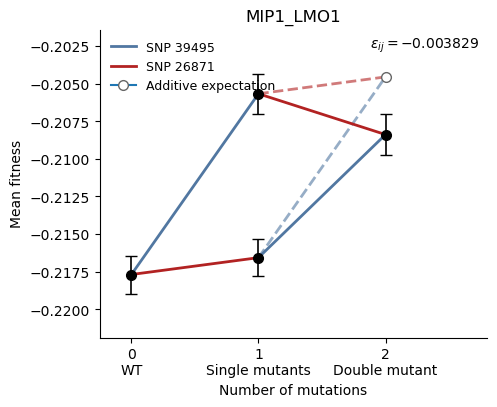

MIP1 VPS70


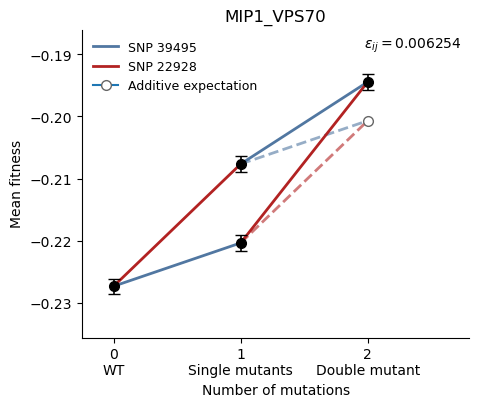

MIP1 BUL2


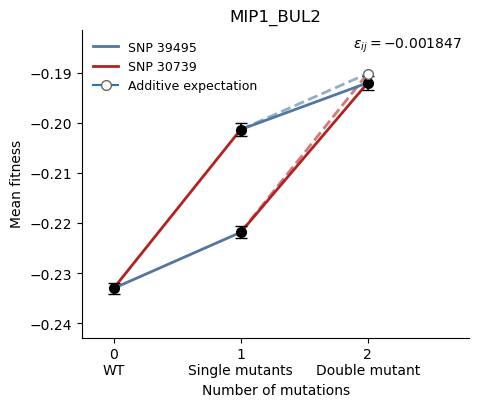

MIP1 VPS36


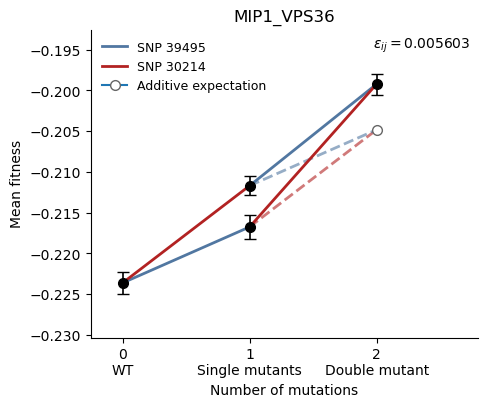

MIP1 RSF1


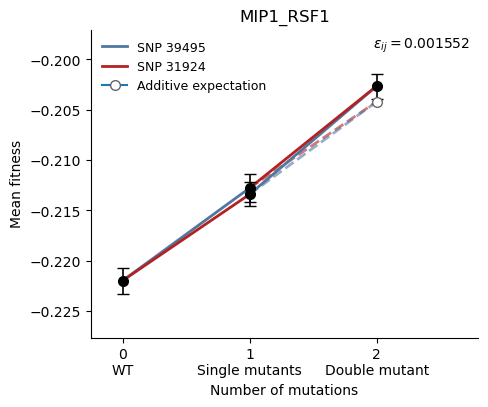

HAL9 LMO1


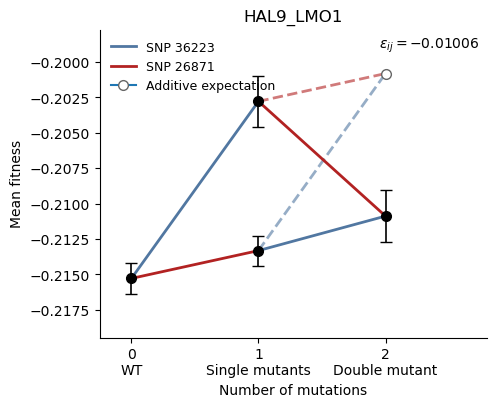

HAL9 VPS70


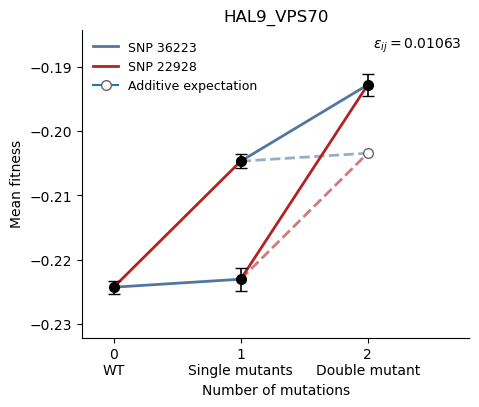

HAL9 BUL2


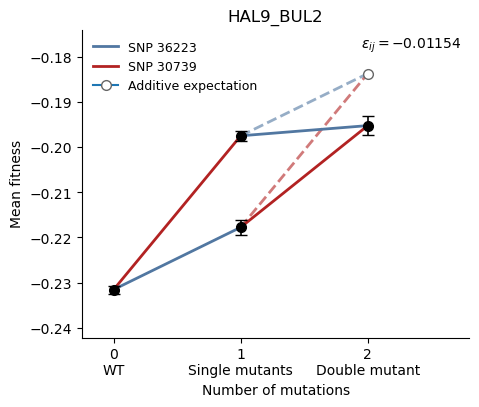

HAL9 VPS36


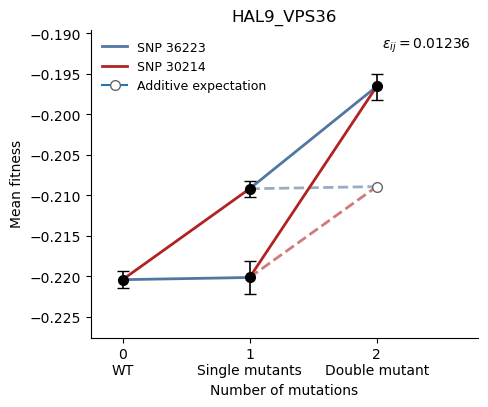

HAL9 RSF1


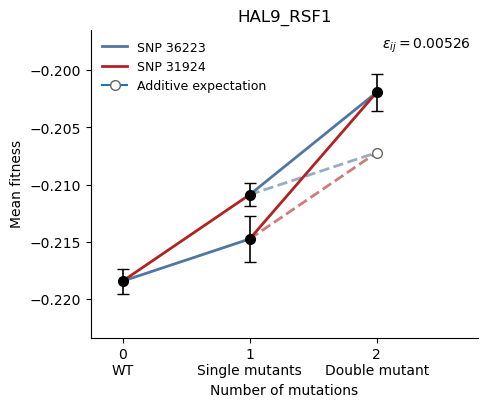

LMO1 VPS70


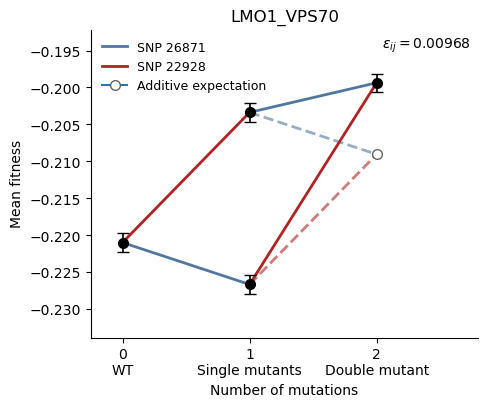

LMO1 BUL2


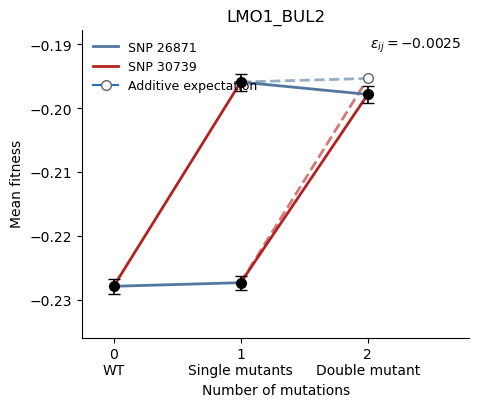

LMO1 VPS36


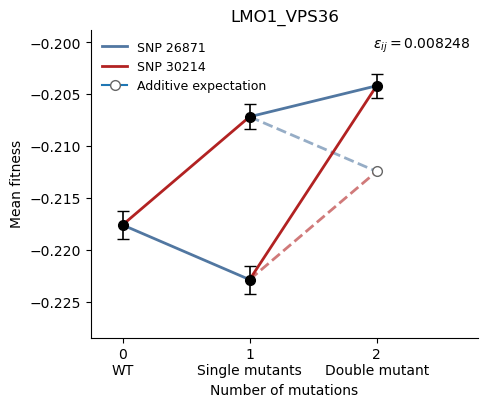

LMO1 RSF1


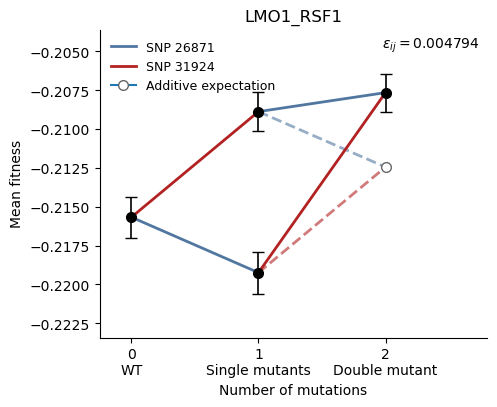

VPS70 BUL2


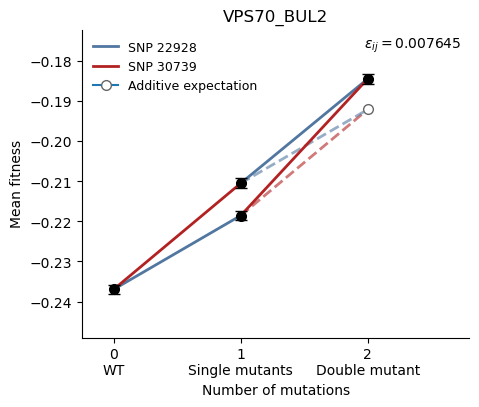

VPS70 VPS36


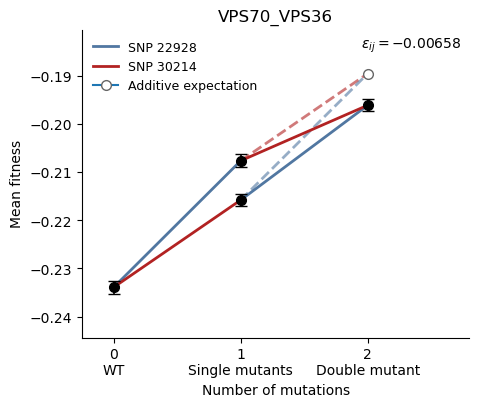

VPS70 RSF1


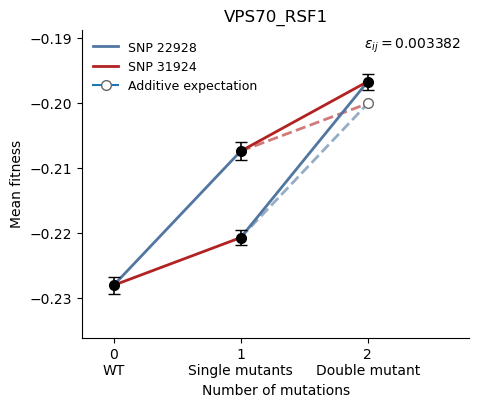

BUL2 VPS36


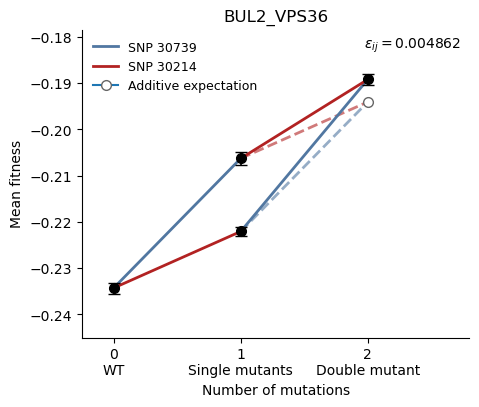

BUL2 RSF1


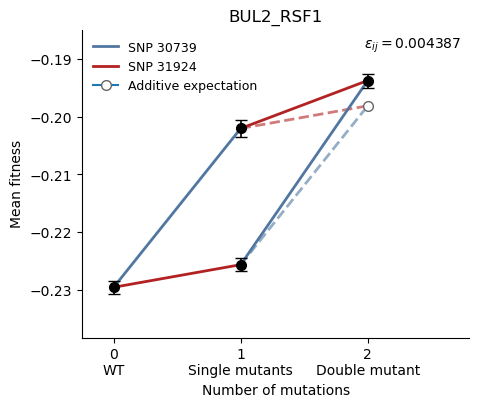

VPS36 RSF1


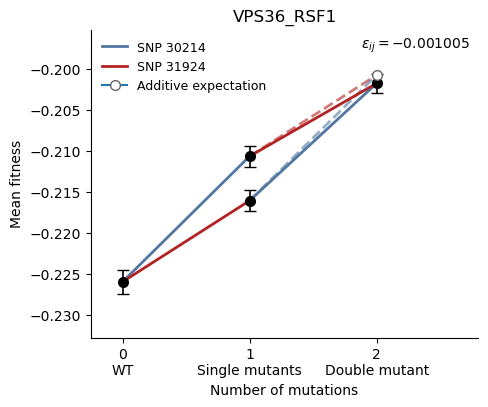

In [8]:
# from itertools import combinations
# from yeast_analysis.gene_hub_analysis import plot_epistatic_parallelogram_onehot

# for gene_a, gene_b in combinations(hub_genes, 2):
#     print(gene_a, gene_b)
    

#     i, j = gene_snps[gene_a][0], gene_snps[gene_b][0]

#     epsilon_ij = epistatic_coefficient_onehot(genotypes, fitness, i=i, j=j)

#     fig, ax, epsilon_ij = plot_epistatic_parallelogram_onehot(
#         genotypes, fitness, i=i, j=j,
#         bootstrap_errors=True,
#         n_bootstrap=10000,
#         confidence_level=0.95,
#         bootstrap_seed=42,
#         show_genotype_labels=False,
#         show_counts=False,
#     )
#     ax.set_title(f'{gene_a}_{gene_b}')
#     plt.show()

In [9]:
gene_info

,chrom,gene_chr_start,gene_chr_end,gene_name
gene_standard_name,,,,
FLO9,1,24000,27968,YAL063C
GDH3,1,31567,32940,YAL062W
BDH2,1,33448,34701,YAL061W
BDH1,1,35155,36303,YAL060W
ECM1,1,36496,36918,YAL059C-A
...,...,...,...,...
AQY1,16,921860,922777,YPR192W
HPA2,16,922909,923379,YPR193C
OPT2,16,924304,926937,YPR194C


In [13]:
snp_info = snp_info.set_index('Unnamed: 0')

In [14]:
snp_info.to_csv("snp_info.csv")

### Find the strongest SNP-SNP interaction

In [9]:
from ld_matched_gene_set_sampler import LDMatchedGeneSetSampler

sampler = LDMatchedGeneSetSampler(
    data=data,
    gene_snps=gene_snps,
    seed=42,
)

/blue/juannanzhou/juannanzhou/conda/envs/gpy5/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Constructed gene vectors: 500/4931
Constructed gene vectors: 1000/4931
Constructed gene vectors: 1500/4931
Constructed gene vectors: 2000/4931
Constructed gene vectors: 2500/4931
Constructed gene vectors: 3000/4931
Constructed gene vectors: 3500/4931
Constructed gene vectors: 4000/4931
Constructed gene vectors: 4500/4931
Calculated LD rows: 512/4931
Calculated LD rows: 1024/4931
Calculated LD rows: 1536/4931
Calculated LD rows: 2048/4931
Calculated LD rows: 2560/4931
Calculated LD rows: 3072/4931
Calculated LD rows: 3584/4931
Calculated LD rows: 4096/4931
Calculated LD rows: 4608/4931
Calculated LD rows: 4931/4931
Stored 4931 x 4931 gene LD matrix (46.4 MB)


#### empirical epistatic coeff based

In [14]:
import gene_hub_analysis
importlib.reload(gene_hub_analysis)

results, linked_a, linked_b = (
    gene_hub_analysis.linked_gene_pair_epistasis(
        gene_a="LMO1",
        gene_b="SMA1",
        genotypes=genotypes,
        fitness=fitness,
        gene_snps=gene_snps,
        sampler=sampler,
        gene_info=gene_info,
        ld_threshold=0.99,
        keep_gene_a=True,
    )
)

display(results)

,gene1,gene2,max_epsilon,max_epsilon_squared,snp_i,snp_j,n_snp_pairs,n_valid_pairs,n_missing_class_pairs
0,LMO1,SMA1,-0.005289,0.000028,26871,40908,72,72,0


#### marginal VC based

In [3]:
from vcme.marginals import MargEpistasis, get_aKa
from vcme.kernels import SiteMarginalKernel, EpKernel, seq_at_p, PathwayMarginalKernel
from tqdm import tqdm

import importlib
import vcme.marginals
importlib.reload(vcme.marginals)
from vcme.marginals import MargEpistasis
from vcme.kernels import PathwayMarginalKernel


from epikVC.models import GPModel, make_GP_model, load_GP_model

n_devices = 1
k_max = 8
device = 'cuda:0'

GP = load_GP_model(checkpoint_path + model_name)
train_x, train_y = GP.genos, GP.y
A, L = 2, int(train_x.shape[1]/2)

log_lda = GP.get_lda()
alpha = GP.get_alpha()

marg = MargEpistasis(A, L, train_x, train_y, alpha, log_lda, chunk_size=10**10, beta_samples=None)



In [11]:
import gene_hub_analysis

importlib.reload(gene_hub_analysis)

results, linked_a, linked_b = (
    gene_hub_analysis.linked_gene_pair_subset_interaction(
        gene_a="LMO1",
        gene_b="SMA1",
        marg=marg,
        gene_snps=gene_snps,
        sampler=sampler,
        gene_info=gene_info,
        ld_threshold=0.95,
        keep_gene_a=False,
    )
)

display(results)

,gene1,gene2,max_interaction,snp_i,snp_j,n_snp_pairs
0,LMO1,SMA1,2.711568e-16,26875,40906,72
1,LMO1,SKS1,2.694918e-16,26875,40909,90
2,SPO75,SMA1,2.671995e-16,26879,40906,36
3,YLL006W-A,SMA1,2.670132e-16,26877,40906,12
4,SPO75,SKS1,2.655466e-16,26879,40909,45
5,YLL006W-A,SKS1,2.653610e-16,26877,40909,15
6,LMO1,ERG10,2.577388e-16,26875,40893,48
7,LMO1,RMI1,2.541544e-16,26875,40932,54
8,SPO75,ERG10,2.538810e-16,26879,40893,24
9,YLL006W-A,ERG10,2.536995e-16,26877,40893,8
